In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from hydrax.utils.files import get_data_path, get_img_path, mkdir
from hydrax.utils.plotting import draw_t, quat_to_yaw_manual, subsample_to_target

sns.set(font_scale=1.7, rc={'font.size':17, 'font.family':'serif'})
img_path = get_img_path()


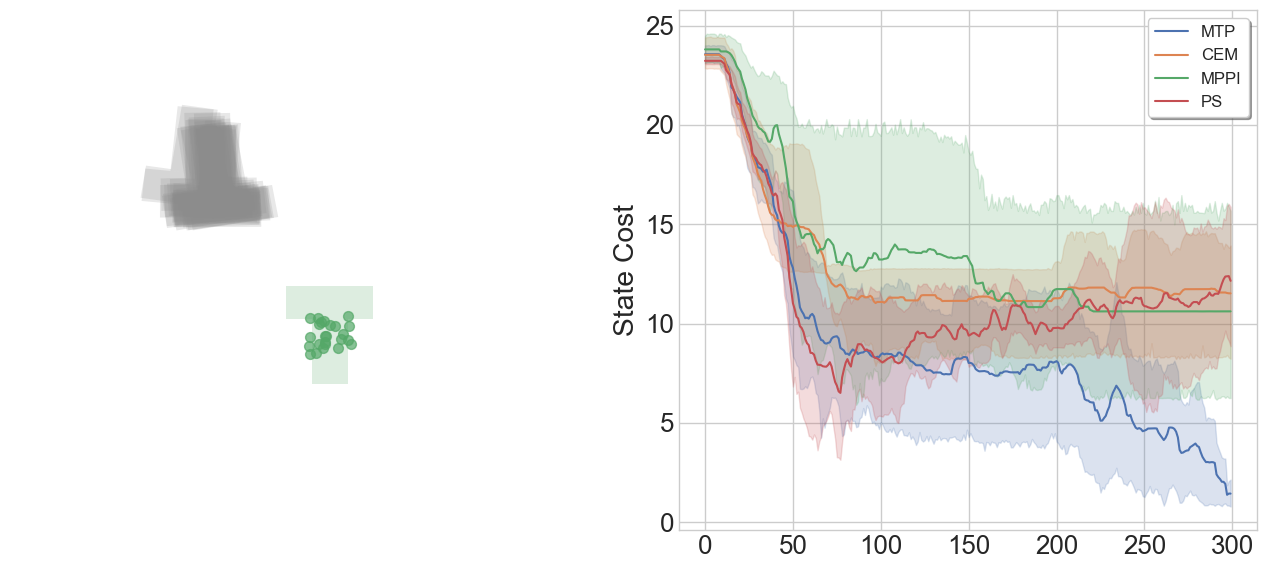

<Figure size 640x480 with 0 Axes>

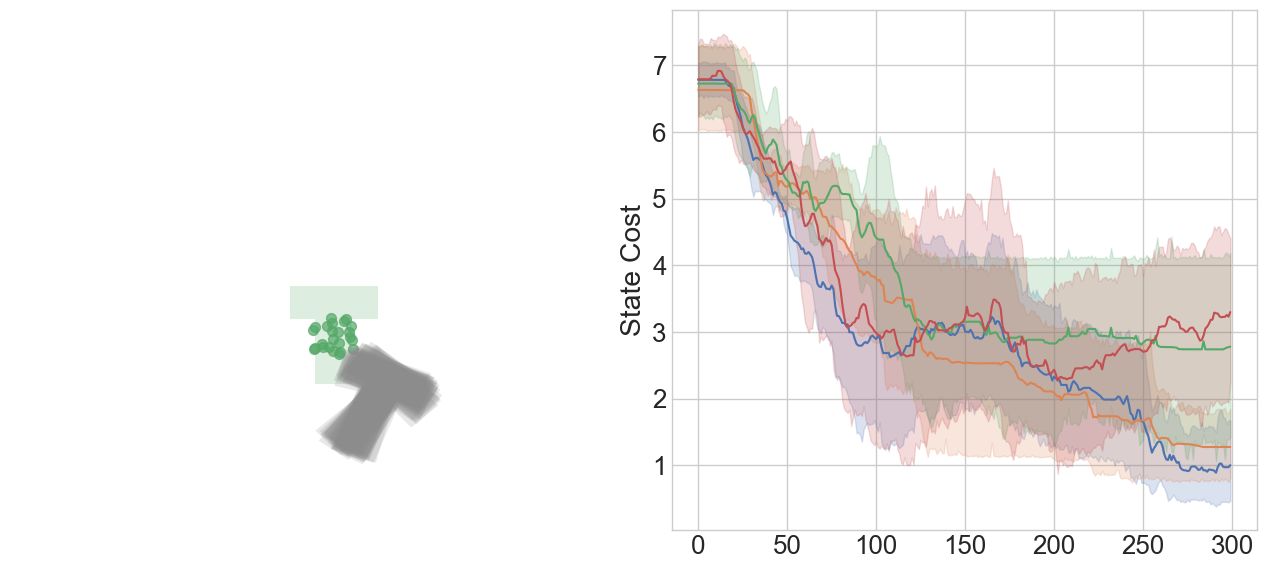

<Figure size 640x480 with 0 Axes>

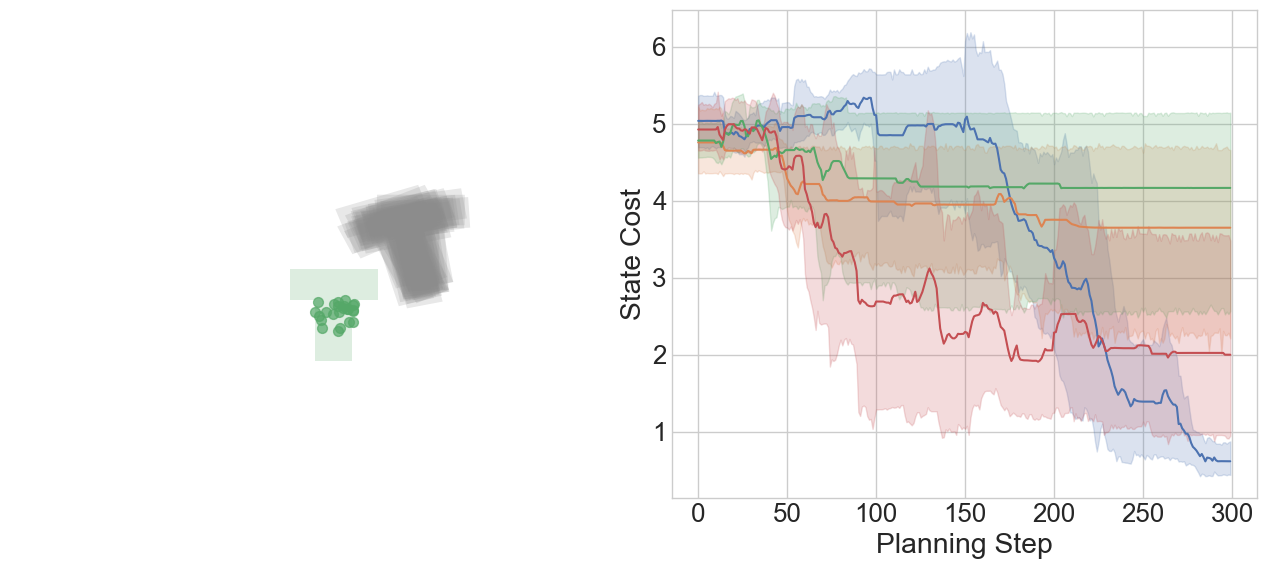

<Figure size 640x480 with 0 Axes>

In [4]:
experiments = [[20, 21, 22, 23, 24, 25],
               [40, 41, 42, 43, 44, 45],
               [50, 51, 52, 53, 54, 55]]


for seeds, idx in zip(experiments, range(len(experiments))):
    # Collect all data into long-form DataFrame
    df_list = []
    init_T = []

    for algo in ["MTP", "CEM", "MPPI", "PredictiveSampling"]:
        for seed in seeds:
            
            path = get_data_path() / "sim-real-free" / f"fr3_pusht_{algo}_seed{seed}.pkl"
            with open(path, "rb") as f:
                data = pickle.load(f)
                
            data = subsample_to_target(data, target_steps=300)  
                
            quat = np.array(data[0]['object_quat'])
            # quat to yaw
            jaw = quat_to_yaw_manual(quat[3], quat[0], quat[1], quat[2])
            x = data[5]['object_pos'][0]
            y = data[5]['object_pos'][1]
            if idx == 0:
                x += 0.1
            elif idx == 1:
                x -= 0.1
            elif idx == 2:
                x += 0.1
                jaw += 2*np.pi/4
            label = "PS" if algo == "PredictiveSampling" else algo
            init_T.append(np.concatenate((np.array([x, y]), np.array([jaw]))))
            timestep = np.arange(min(400, len(data)))
            df_list.append(pd.DataFrame({
                'timestep': timestep,
                'terminal_error': [d["terminal_error"] for d in data[:400]],
                'algo': label,
                'seed': seed
            }))

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    df = pd.concat(df_list)
    init_Ts = np.array(init_T)


    init_ee = np.ones((init_Ts.shape[0], 2)) * np.array([0.0425, 0.5])
    init_ee += np.random.uniform(-0.03, 0.03, size=init_ee.shape)
    # plot
    axes[0].scatter(init_ee[:, 0], init_ee[:, 1], s=50, c='C2', alpha=0.7, label='Initial end-effector')
    draw_t(axes[0], 0.0, 0.5, 0.0, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
            face_alpha=0.2, facecolor='C2')

    # draw Ts
    for i in range(init_Ts.shape[0]):
        x, y, yaw = init_Ts[i]
        yaw += -np.pi/2
        draw_t(axes[0], -y, x, yaw, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
            face_alpha=0.2, facecolor='C7')

    axes[0].set_xlim([-0.4, 0.4])
    axes[0].set_ylim([0.2, 1.0])
    # remove ticks
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    # remove border
    for spine in axes[0].spines.values():
        spine.set_visible(False)

    sns.lineplot(data=df, x='timestep', y='terminal_error', hue='algo', ax=axes[1])
    if idx == 2:
        axes[1].set_xlabel("Planning Step")
    else:
        axes[1].set_xlabel("")
    axes[1].set_ylabel("State Cost")
    if idx == 0:
        axes[1].legend(
            loc='upper right',           # Position: 'upper right', 'lower center', etc.
            frameon=True,                # Box around legend
            fancybox=True,               # Rounded box
            shadow=True,                 # Drop shadow
            ncol=1,                      # Columns (1=vertical)
            fontsize=12                  # Text size
        )
    else:
        axes[1].legend_.remove()
    plt.tight_layout()
    plt.show()
   
    mkdir(f"{img_path}/fr3/free")
    plt.savefig(f"{img_path}/fr3/free/fr3_rollout_{idx}.pdf", bbox_inches='tight')

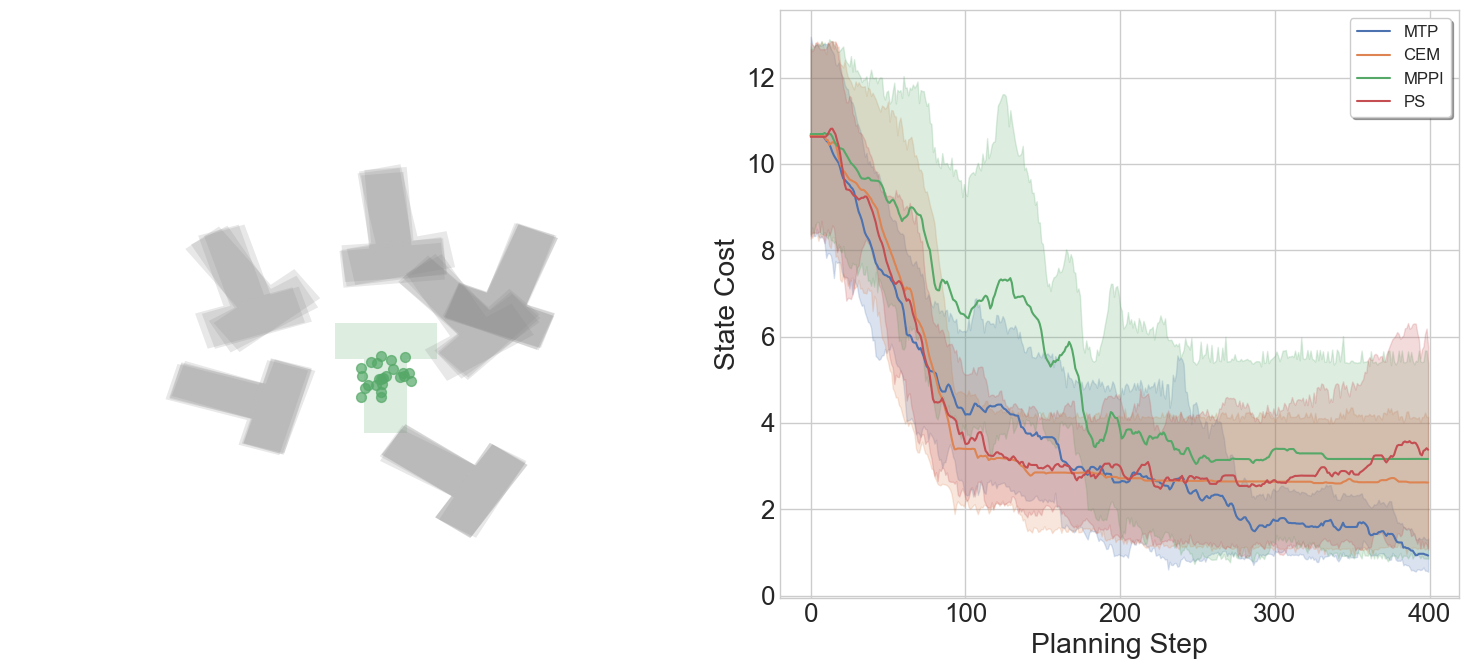

<Figure size 640x480 with 0 Axes>

In [5]:
seeds = [0, 1, 2, 3, 5, 6]


# Collect all data into long-form DataFrame
df_list = []
init_T = []

for algo in ["MTP", "CEM", "MPPI", "PredictiveSampling"]:
    for seed in seeds:
        
        path = get_data_path() / "sim-real-3dof" / f"fr3_pusht_{algo}_seed{seed}.pkl"
        with open(path, "rb") as f:
            data = pickle.load(f)
            
        quat = np.array(data[0]['object_quat'])
        # quat to yaw
        jaw = quat_to_yaw_manual(quat[3], quat[0], quat[1], quat[2]) + np.pi/2


        x = data[5]['object_pos'][0]
        y = data[5]['object_pos'][1]
        if seed in [1]:
            x -= 0.1
        elif seed in [6]:
            x += 0.1
        label = "PS" if algo == "PredictiveSampling" else algo
        init_T.append(np.concatenate((np.array([x, y]), np.array([jaw]))))
        timestep = np.arange(min(400, len(data)))
        df_list.append(pd.DataFrame({
            'timestep': timestep,
            'terminal_error': [d["terminal_error"] for d in data[:400]],
            'algo': label,
            'seed': seed
        }))

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
df = pd.concat(df_list)
init_Ts = np.array(init_T)


init_ee = np.ones((init_Ts.shape[0], 2)) * np.array([0.0425, 0.5])
init_ee += np.random.uniform(-0.03, 0.03, size=init_ee.shape)
# plot
axes[0].scatter(init_ee[:, 0], init_ee[:, 1], s=50, c='C2', alpha=0.7, label='Initial end-effector')
draw_t(axes[0], 0.0, 0.5, 0.0, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
           face_alpha=0.2, facecolor='C2')

# draw Ts
for i in range(init_Ts.shape[0]):
    x, y, yaw = init_Ts[i]
    yaw += np.pi/2
    draw_t(axes[0], -y, x, yaw, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
           face_alpha=0.2, facecolor='C7')

axes[0].set_xlim([-0.4, 0.4])
axes[0].set_ylim([0.2, 1.0])
# remove ticks
axes[0].set_xticks([])
axes[0].set_yticks([])
# remove border
for spine in axes[0].spines.values():
    spine.set_visible(False)


sns.lineplot(data=df, x='timestep', y='terminal_error', hue='algo', ax=axes[1])
axes[1].set_xlabel("Planning Step")
axes[1].set_ylabel("State Cost")
axes[1].legend(
    loc='upper right',           # Position: 'upper right', 'lower center', etc.
    frameon=True,                # Box around legend
    fancybox=True,               # Rounded box
    shadow=True,                 # Drop shadow
    ncol=1,                      # Columns (1=vertical)
    fontsize=12                  # Text size
)
plt.tight_layout()
plt.show()
mkdir(f"{img_path}/fr3/joint")
plt.savefig(f"{img_path}/fr3/joint/fr3_pusht_3dof_results.pdf", bbox_inches='tight')